### Tensorflow and keras 

In [32]:
import numpy as np
import matplotlib.pyplot as plt

In [16]:
#pip install tensorflow

In [33]:
import tensorflow as tf
from tensorflow import keras

In [34]:
from tensorflow.keras.preprocessing.image import load_img

In [35]:
path = './clothing-dataset-small/train/hat'
name = '00d94e21-5891-492e-be0e-792e7338c077.jpg'
fullname = f'{path}/{name}'


In [36]:
img = load_img(fullname, target_size=(299, 299))

In [37]:
X = np.array(img)
X.shape

(299, 299, 3)

In [22]:
X

array([[[161,  15,  15],
        [161,  15,  15],
        [161,  15,  15],
        ...,
        [113,   9,   6],
        [112,   8,   5],
        [110,   8,   4]],

       [[161,  15,  15],
        [161,  15,  15],
        [161,  15,  15],
        ...,
        [118,  10,   8],
        [115,  10,   7],
        [113,   9,   6]],

       [[161,  15,  15],
        [161,  15,  15],
        [161,  15,  15],
        ...,
        [126,  12,  12],
        [124,  12,  11],
        [121,  11,  10]],

       ...,

       [[101,   5,   7],
        [101,   5,   7],
        [101,   5,   7],
        ...,
        [124,  10,  10],
        [126,  12,  12],
        [128,  14,  14]],

       [[101,   5,   7],
        [101,   5,   7],
        [101,   5,   7],
        ...,
        [125,  11,  11],
        [126,  12,  12],
        [128,  14,  14]],

       [[101,   5,   7],
        [101,   5,   7],
        [101,   5,   7],
        ...,
        [125,  11,  11],
        [126,  12,  12],
        [127,  13,  13]]

### Pre-trained convolutional neural networks

https://www.image-net.org/

https://keras.io/api/applications/

In [38]:
from tensorflow.keras.applications.xception import Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.applications.xception import decode_predictions

In [39]:
model = Xception(weights='imagenet', input_shape=(299, 299, 3))

In [25]:
X = np.array([X])

In [26]:
X = preprocess_input(X)

In [27]:
X[0]

array([[[ 0.26274514, -0.88235295, -0.88235295],
        [ 0.26274514, -0.88235295, -0.88235295],
        [ 0.26274514, -0.88235295, -0.88235295],
        ...,
        [-0.11372548, -0.92941177, -0.9529412 ],
        [-0.12156862, -0.9372549 , -0.9607843 ],
        [-0.1372549 , -0.9372549 , -0.96862745]],

       [[ 0.26274514, -0.88235295, -0.88235295],
        [ 0.26274514, -0.88235295, -0.88235295],
        [ 0.26274514, -0.88235295, -0.88235295],
        ...,
        [-0.0745098 , -0.92156863, -0.9372549 ],
        [-0.09803921, -0.92156863, -0.94509804],
        [-0.11372548, -0.92941177, -0.9529412 ]],

       [[ 0.26274514, -0.88235295, -0.88235295],
        [ 0.26274514, -0.88235295, -0.88235295],
        [ 0.26274514, -0.88235295, -0.88235295],
        ...,
        [-0.01176471, -0.90588236, -0.90588236],
        [-0.02745098, -0.90588236, -0.9137255 ],
        [-0.05098039, -0.9137255 , -0.92156863]],

       ...,

       [[-0.20784312, -0.9607843 , -0.94509804],
        [-0

In [28]:
pred = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [29]:
pred.shape

(1, 1000)

In [30]:
decode_predictions(pred)

[[('n03424325', 'gasmask', np.float32(0.1535756)),
  ('n02769748', 'backpack', np.float32(0.089838855)),
  ('n03709823', 'mailbag', np.float32(0.064012595)),
  ('n03595614', 'jersey', np.float32(0.04093369)),
  ('n02834397', 'bib', np.float32(0.024432804))]]

### Transfer learning

In [40]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [32]:
train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_ds = train_gen.flow_from_directory('./clothing-dataset-small/train'
                                         , target_size=(150, 150), 
                                         class_mode='sparse', 
                                         batch_size=32)

Found 3068 images belonging to 10 classes.


In [33]:
train_ds.class_indices

{'dress': 0,
 'hat': 1,
 'longsleeve': 2,
 'outwear': 3,
 'pants': 4,
 'shirt': 5,
 'shoes': 6,
 'shorts': 7,
 'skirt': 8,
 't-shirt': 9}

In [34]:
X,y = next(train_ds)

In [35]:
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
val_ds = val_gen.flow_from_directory('./clothing-dataset-small/validation'
                                       , target_size=(150, 150), 
                                       class_mode='sparse',
                                       shuffle=False, 
                                       batch_size=32)

Found 341 images belonging to 10 classes.


In [36]:
base_model =Xception(
    weights='imagenet',
    include_top=False,
    input_shape=(150, 150, 3)
)
base_model.trainable = False

In [37]:
inputs = keras.Input(shape=(150, 150, 3))

base = base_model(inputs, training=False)

vectors = keras.layers.GlobalAveragePooling2D()(base)

outputs = keras.layers.Dense(10)(vectors)

model = keras.Model(inputs, outputs)

In [38]:
preds = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [39]:
preds.shape

(32, 10)

In [40]:
preds[0]

array([ 0.46508157,  0.07188994,  0.64865357,  0.58688295, -0.5315911 ,
        0.72617644,  1.001662  ,  0.0271531 ,  0.55159724,  0.72461975],
      dtype=float32)

In [41]:
learning_rate=0.01
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

loss = keras.losses.SparseCategoricalCrossentropy(from_logits=True)

In [42]:
model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy']) 

In [43]:
history = model.fit(train_ds, epochs=5, validation_data=val_ds)

Epoch 1/5
96/96 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.6760 - loss: 1.1901 - val_accuracy: 0.7507 - val_loss: 0.8817
Epoch 2/5
96/96 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.8155 - loss: 0.6156 - val_accuracy: 0.7771 - val_loss: 0.8631
Epoch 3/5
96/96 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - accuracy: 0.8683 - loss: 0.4343 - val_accuracy: 0.7918 - val_loss: 0.8672
Epoch 4/5
96/96 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.9185 - loss: 0.2259 - val_accuracy: 0.8006 - val_loss: 0.8461
Epoch 5/5
96/96 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.9319 - loss: 0.1725 - val_accuracy: 0.7801 - val_loss: 0.9511


In [44]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

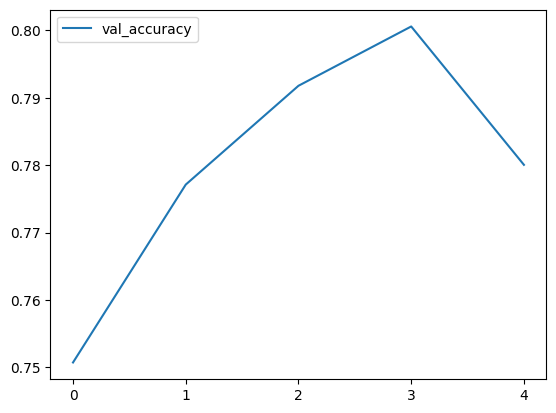

In [45]:
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xticks(np.arange(5))
plt.legend()

### Adjusting learning rate

In [46]:
def make_model(learning_rate):
    base_model =Xception(
    weights='imagenet',
    include_top=False,
    input_shape=(150, 150, 3)
        )
    base_model.trainable = False
    #######################################################################
    inputs = keras.Input(shape=(150, 150, 3))
    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)
    outputs = keras.layers.Dense(10)(vectors)
    model = keras.Model(inputs, outputs)
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.SparseCategoricalCrossentropy(from_logits=True)
    #######################################################################
    model.compile(optimizer=optimizer,
                   loss=loss,
                   metrics=['accuracy']) 
    return model

In [47]:
scores = {}
for lr in [0.01,0.1, 0.001, 0.0001]:
    print(f'Training model with learning rate: {lr}')
    model = make_model(lr)
    history = model.fit(train_ds, epochs=5, validation_data=val_ds)
    scores[lr] = history.history

    print()
    print()

Training model with learning rate: 0.01
Epoch 1/5


96/96 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.6649 - loss: 1.3403 - val_accuracy: 0.7859 - val_loss: 0.7514
Epoch 2/5
96/96 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - accuracy: 0.8263 - loss: 0.5412 - val_accuracy: 0.7742 - val_loss: 0.8067
Epoch 3/5
46/96 ━━━━━━━━━━━━━━━━━━━━ 1:04 1s/step - accuracy: 0.8777 - loss: 0.3404

KeyboardInterrupt: 

In [ ]:
del scores[0.0001]
del scores [0.1]

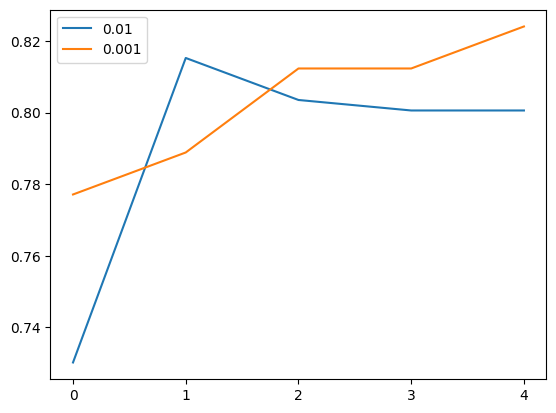

In [ ]:
for lr, hist in scores.items():
    plt.plot(hist['val_accuracy'], label=lr)
plt.xticks(np.arange(5))
plt.legend()

In [ ]:
learning_rate = 0.001

### Checkpointing

In [ ]:
model.save_weights('model_v1.weights.h5') 



In [ ]:
'exception_v1_{epoch:02d}_{val_accuracy:.3f}.h5'.format(epoch=3, val_accuracy=0.876)

'exception_v1_03_0.876.h5'

In [ ]:
checkpoint = keras.callbacks.ModelCheckpoint('exception_v1_{epoch:02d}_lr{val_accuracy:.3f}.h5',
                               save_best_only=True,
                               monitor='val_accuracy',
                               mode='max')

In [ ]:
learning_rate = 0.001
model = make_model(learning_rate=learning_rate)
history = model.fit(
    train_ds,
    epochs=5,
    validation_data=val_ds,
    callbacks=[checkpoint]
)

Epoch 1/5
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5117 - loss: 1.4696

96/96 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.6346 - loss: 1.0910 - val_accuracy: 0.7918 - val_loss: 0.7133
Epoch 2/5
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7770 - loss: 0.6573

96/96 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - accuracy: 0.7846 - loss: 0.6264 - val_accuracy: 0.8035 - val_loss: 0.6228
Epoch 3/5
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8359 - loss: 0.5161

96/96 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - accuracy: 0.8351 - loss: 0.5042 - val_accuracy: 0.8094 - val_loss: 0.5902
Epoch 4/5
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8661 - loss: 0.4203

96/96 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.8660 - loss: 0.4269 - val_accuracy: 0.8123 - val_loss: 0.5682
Epoch 5/5
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9009 - loss: 0.3584

96/96 ━━━━━━━━━━━━━━━━━━━━ 130s 1s/step - accuracy: 0.8937 - loss: 0.3662 - val_accuracy: 0.8240 - val_loss: 0.5655


### Adding more layers

In [48]:
def make_model(learning_rate,size_inner=100):
    base_model =Xception(
    weights='imagenet',
    include_top=False,
    input_shape=(150, 150, 3)
        )
    base_model.trainable = False
    #######################################################################
    inputs = keras.Input(shape=(150, 150, 3))
    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)

    inner = keras.layers.Dense(size_inner, activation='relu')(vectors)

    outputs = keras.layers.Dense(10)(inner)
    model = keras.Model(inputs, outputs)
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.SparseCategoricalCrossentropy(from_logits=True)
    #######################################################################
    model.compile(optimizer=optimizer,
                   loss=loss,
                   metrics=['accuracy']) 
    return model

In [56]:
learning_rate = 0.001
scores = {}
for size in [10,100,1000]:
    print(size)
    model = make_model(learning_rate=learning_rate,size_inner=size)
    history = model.fit(train_ds, epochs=5, validation_data=val_ds)
    scores[size] = history.history

    print()
    print()

10
Epoch 1/5
96/96 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.4958 - loss: 1.4222 - val_accuracy: 0.6686 - val_loss: 1.0085
Epoch 2/5
96/96 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.6874 - loss: 0.8949 - val_accuracy: 0.7361 - val_loss: 0.8231
Epoch 3/5
96/96 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.7630 - loss: 0.7092 - val_accuracy: 0.7654 - val_loss: 0.7306
Epoch 4/5
63/96 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.8080 - loss: 0.5968

KeyboardInterrupt: 

In [50]:
scores

{0.01: {'accuracy': [0.6958931088447571,
   0.8275749683380127,
   0.9048240184783936,
   0.9501304030418396,
   0.9768579006195068],
  'loss': [0.9244021773338318,
   0.478849858045578,
   0.2754475176334381,
   0.1595478355884552,
   0.09195517003536224],
  'val_accuracy': [0.759530782699585,
   0.7829912304878235,
   0.8357771039009094,
   0.7976539731025696,
   0.8064516186714172],
  'val_loss': [0.6590775847434998,
   0.665246844291687,
   0.595155656337738,
   0.6555625200271606,
   0.694688081741333]}}

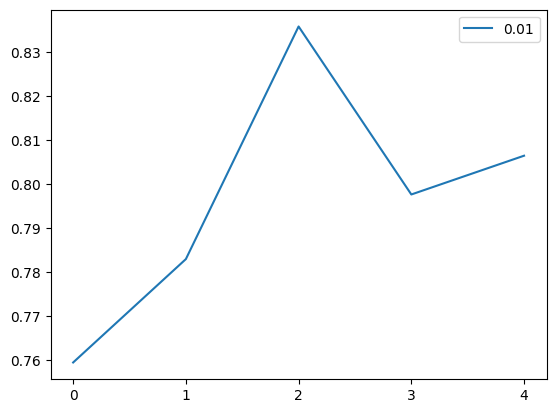

In [55]:
for size, hist in scores.items():
    plt.plot(hist['val_accuracy'], label=size)
plt.xticks(np.arange(5))
plt.legend()

### drop rate

In [10]:
def make_model(learning_rate,size_inner=100,droprate=0.5):
    base_model =Xception(
    weights='imagenet',
    include_top=False,
    input_shape=(150, 150, 3)
        )
    base_model.trainable = False
    #######################################################################
    #######################################################################
    inputs = keras.Input(shape=(150, 150, 3))
    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)

    inner = keras.layers.Dense(size_inner, activation='relu')(vectors)
    drop = keras.layers.Dropout(droprate)(inner)
    outputs = keras.layers.Dense(10)(drop)
    model = keras.Model(inputs, outputs)
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.SparseCategoricalCrossentropy(from_logits=True)
    #######################################################################
    model.compile(optimizer=optimizer,
                   loss=loss,
                   metrics=['accuracy']) 
    return model

In [64]:
learning_rate = 0.001
size= 100
scores = {}
for droprate in [0.0,0.2,0.5,0.8]:
    print(droprate)
    model = make_model(learning_rate=learning_rate,size_inner=size,droprate=droprate)
    history = model.fit(train_ds, epochs=1, validation_data=val_ds)
    scores[droprate] = history.history

    print()
    print()

0.0
96/96 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.6855 - loss: 0.9280 - val_accuracy: 0.8270 - val_loss: 0.6153


0.2
96/96 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.6516 - loss: 1.0810 - val_accuracy: 0.7918 - val_loss: 0.6570


0.5
96/96 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.5720 - loss: 1.3039 - val_accuracy: 0.7683 - val_loss: 0.7704


0.8
96/96 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.3810 - loss: 1.8447 - val_accuracy: 0.6569 - val_loss: 1.1938




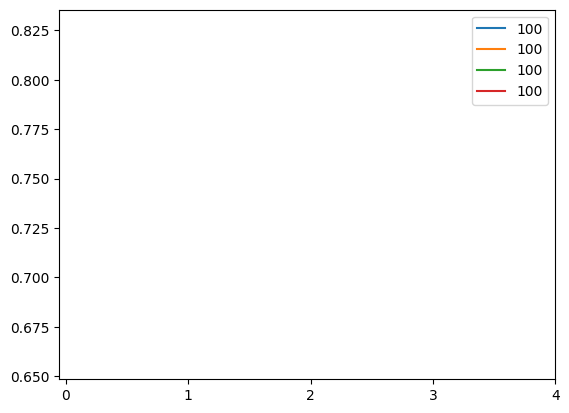

In [65]:
for droprate, hist in scores.items():
    plt.plot(hist['val_accuracy'], label=size)
plt.xticks(np.arange(5))
plt.legend()

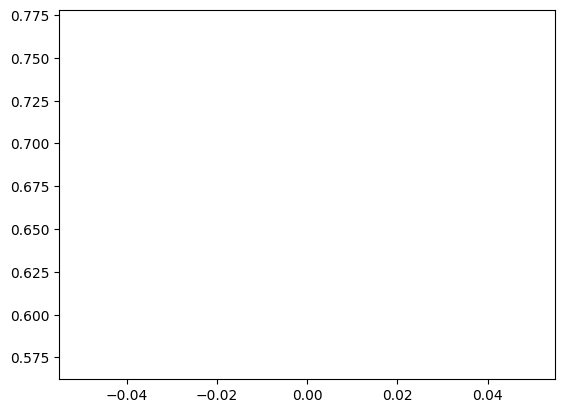

In [67]:
hist = scores[0.5]
plt.plot(hist['val_accuracy'], label='val=%s' % droprate)
plt.plot(hist['accuracy'], label='val=%s' % droprate)

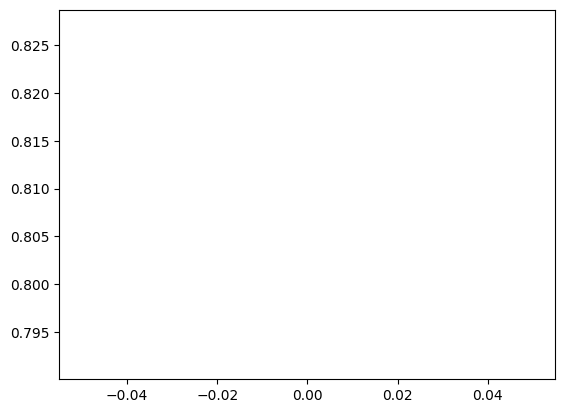

In [68]:
hist = scores[0.0]
plt.plot(hist['val_accuracy'], label='0.0')

hist = scores[0.2]
plt.plot(hist['val_accuracy'], label='0.2') 

### Data Augmentation

In [17]:
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    shear_range=10,
    zoom_range=0.1,
    vertical_flip=True,
    )
 
train_ds = train_gen.flow_from_directory(
        './clothing-dataset-small/train',
        target_size=(150, 150),
        class_mode='sparse',
        batch_size=32
)
 
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
 
val_ds = val_gen.flow_from_directory(
        './clothing-dataset-small/validation',
        target_size=(150, 150),
        class_mode='sparse',
        batch_size=32,
        shuffle=False
)
 

Found 3068 images belonging to 10 classes.
Found 341 images belonging to 10 classes.
Found 341 images belonging to 10 classes.


In [18]:
train_gen = ImageDataGenerator(preprocessing_function=preprocess_input,
#     vertical_flip=True,
 )
 
train_ds = train_gen.flow_from_directory(
     './clothing-dataset-small/train',
     target_size=(150, 150),
     class_mode='sparse',
     batch_size=32
 )
 
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
 
val_ds = val_gen.flow_from_directory(
     './clothing-dataset-small/validation',
     target_size=(150, 150),
     class_mode='sparse',
     batch_size=32,
     shuffle=False
 )

Found 3068 images belonging to 10 classes.
Found 341 images belonging to 10 classes.
Found 341 images belonging to 10 classes.


"""
Note: We use class_mode='sparse' to produce integer labels (shape `(batch,)`) so the loss `SparseCategoricalCrossentropy` works correctly.
If you have one-hot labels (shape `(batch, num_classes)`), use `class_mode='categorical'` and `loss=keras.losses.CategoricalCrossentropy(from_logits=True)`.
"""

In [ ]:
learning_rate = 0.001
size = 100
droprate = 0.2
 
model = make_model(
    learning_rate=learning_rate,
    size_inner=size,
    droprate=droprate
)
 
history = model.fit(train_ds, epochs=50, validation_data=val_ds)

Epoch 1/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.6369 - loss: 1.1004 - val_accuracy: 0.7683 - val_loss: 0.7260
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.6369 - loss: 1.1004 - val_accuracy: 0.7683 - val_loss: 0.7260
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 150s 2s/step - accuracy: 0.7862 - loss: 0.6403 - val_accuracy: 0.8094 - val_loss: 0.6258
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 150s 2s/step - accuracy: 0.7862 - loss: 0.6403 - val_accuracy: 0.8094 - val_loss: 0.6258
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8331 - loss: 0.4670

KeyboardInterrupt: 

In [ ]:
hist = scores[0.0]
plt.plot(hist['val_accuracy'], label='val')

hist = scores[0.2]
plt.plot(hist['accuracy'], label='train') 

plt.legend()

### Training a Larger Model

In [41]:
def make_model(input_size = 150,learning_rate=0.01,size_inner=100,droprate=0.5):
    base_model =Xception(
    weights='imagenet',
    include_top=False,
    input_shape=(input_size, input_size, 3)
        )
    base_model.trainable = False
    #######################################################################
    #######################################################################
    inputs = keras.Input(shape=(input_size, input_size, 3))
    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)

    inner = keras.layers.Dense(size_inner, activation='relu')(vectors)
    drop = keras.layers.Dropout(droprate)(inner)
    outputs = keras.layers.Dense(10)(drop)
    model = keras.Model(inputs, outputs)
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.SparseCategoricalCrossentropy(from_logits=True)
    #######################################################################
    model.compile(optimizer=optimizer,
                   loss=loss,
                   metrics=['accuracy']) 
    return model

In [42]:
input_size = 299 

In [46]:
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    shear_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)
 
train_ds = train_gen.flow_from_directory(
    './clothing-dataset-small/train',
    target_size=(input_size, input_size),
    class_mode='sparse',
    batch_size=32
)
 
 
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
 
val_ds = val_gen.flow_from_directory(
    './clothing-dataset-small/validation',
    target_size=(input_size, input_size),
    class_mode='sparse',
    batch_size=32,
    shuffle=False
)


Found 3068 images belonging to 10 classes.
Found 341 images belonging to 10 classes.
Found 341 images belonging to 10 classes.


In [47]:
checkpoint = keras.callbacks.ModelCheckpoint(
    'xception_v4_1_{epoch:02d}_{val_accuracy:.3f}.h5',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)

Note: We set `input_size = 299` above and `target_size=(input_size,input_size)` for the ImageDataGenerator. Make sure to pass `input_size=input_size` when creating models with `make_model()` so the model input shape matches the data target size; otherwise, Keras will raise a shape mismatch ValueError.
Also, we use `class_mode='sparse'` in the generators so `SparseCategoricalCrossentropy` receives integer labels (shape `(batch,)`).

In [ ]:
learning_rate = 0.001
size = 100
droprate = 0.2
 
model = make_model(
    input_size=input_size,
    learning_rate=learning_rate,
    size_inner=size,
    droprate=droprate
)
 
history = model.fit(train_ds, epochs=5, validation_data=val_ds,
                   callbacks=[checkpoint])